# 🛒 Proyek Akhir: Preprocessing & Unsupervised Learning
## Mall Customer Segmentation dengan K-Means Clustering

**Nama:** Ditia Wulandari  
**NIM:** 241011401219  
**Mata Kuliah:** Data Mining  
**Tanggal:** 28/06/2026

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Library berhasil diimport!")

Library berhasil diimport!


## 2. Load dan Eksplorasi Dataset Mentah

In [2]:
df_raw = pd.read_csv('mall_customers_raw.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Shape: (530, 5)


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score
0,141,Female,54.0,127.0,75.0
1,399,male,59.0,67.0,26.0
2,7,female,38.0,36.0,8.0
3,335,male,50.0,78.0,72.0
4,323,Male,42.0,106.0,90.0
5,83,Male,65.0,54.0,74.0
6,226,male,66.0,97.0,85.0
7,497,Female,42.0,NaN,23.0
8,98,Female,58.0,104.0,NaN
9,102,Male,18.0,88.0,40.0


In [3]:
print("=== INFO DATASET ===")
df_raw.info()
print("\n=== MISSING VALUES ===")
print(df_raw.isnull().sum())
print(f"\nJumlah Duplikat: {df_raw.duplicated().sum()}")
print(f"\nNilai unik Gender: {df_raw['Gender'].unique()}")

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       530 non-null    int64  
 1   Gender           473 non-null    str    
 2   Age              504 non-null    float64
 3   Annual_Income_k  504 non-null    float64
 4   Spending_Score   500 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 20.8 KB

=== MISSING VALUES ===
CustomerID          0
Gender             57
Age                26
Annual_Income_k    26
Spending_Score     30
dtype: int64

Jumlah Duplikat: 30

Nilai unik Gender: <StringArray>
['Female', 'male', 'female', 'Male', nan, 'F', 'M']
Length: 7, dtype: str


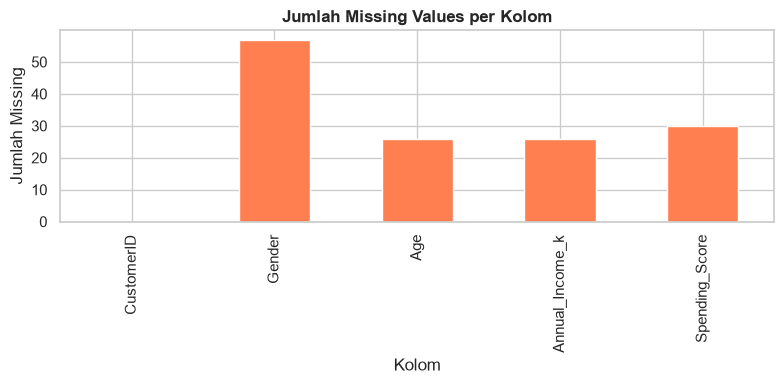

In [4]:
# Visualisasi distribusi missing values
fig, ax = plt.subplots(figsize=(8, 4))
df_raw.isnull().sum().plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Jumlah Missing Values per Kolom', fontweight='bold')
ax.set_xlabel('Kolom')
ax.set_ylabel('Jumlah Missing')
plt.tight_layout()
plt.show()

## 3. Cleaning Data

### 3.1 Hapus Duplikat

In [5]:
df = df_raw.copy()
before = len(df)
df = df.drop_duplicates()
print(f"Baris sebelum: {before} | Setelah: {len(df)} | Duplikat dihapus: {before - len(df)}")

Baris sebelum: 530 | Setelah: 500 | Duplikat dihapus: 30


### 3.2 Standardisasi Nilai Gender

In [6]:
def clean_gender(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ['male', 'm']:
        return 'Male'
    elif v in ['female', 'f']:
        return 'Female'
    return np.nan

df['Gender'] = df['Gender'].apply(clean_gender)
print(f"Distribusi Gender: {df['Gender'].value_counts().to_dict()}")

Distribusi Gender: {'Male': 228, 'Female': 224}


### 3.3 Imputasi Missing Values

In [7]:
# Imputasi numerik dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Annual_Income_k'] = df['Annual_Income_k'].fillna(df['Annual_Income_k'].median())
df['Spending_Score'] = df['Spending_Score'].fillna(df['Spending_Score'].median())

# Imputasi Gender dengan modus
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

print(f"Missing values setelah imputasi: {df.isnull().sum().sum()}")
df.describe()

Missing values setelah imputasi: 0


,CustomerID,Age,Annual_Income_k,Spending_Score
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,44.422000,76.020000,48.548000
std,144.481833,14.670186,34.833696,28.056765
min,1.000000,18.000000,15.000000,1.000000
25%,125.750000,33.000000,47.000000,25.750000
50%,250.500000,45.000000,76.000000,49.000000
75%,375.250000,56.000000,106.000000,71.250000
max,500.000000,69.000000,136.000000,99.000000


### 3.4 Encoding dan Feature Scaling

In [8]:
# Encoding Gender
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Pilih fitur untuk clustering
features = ['Age', 'Annual_Income_k', 'Spending_Score']
X = df[features].copy()

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape fitur: {X.shape}")
print(f"Mean setelah scaling: {X_scaled.mean(axis=0).round(5)}")
print(f"Std setelah scaling:  {X_scaled.std(axis=0).round(5)}")

Shape fitur: (500, 3)
Mean setelah scaling: [ 0.  0. -0.]
Std setelah scaling:  [1. 1. 1.]


## 4. Menentukan K Optimal (Elbow + Silhouette)

K optimal (Silhouette tertinggi): K=6


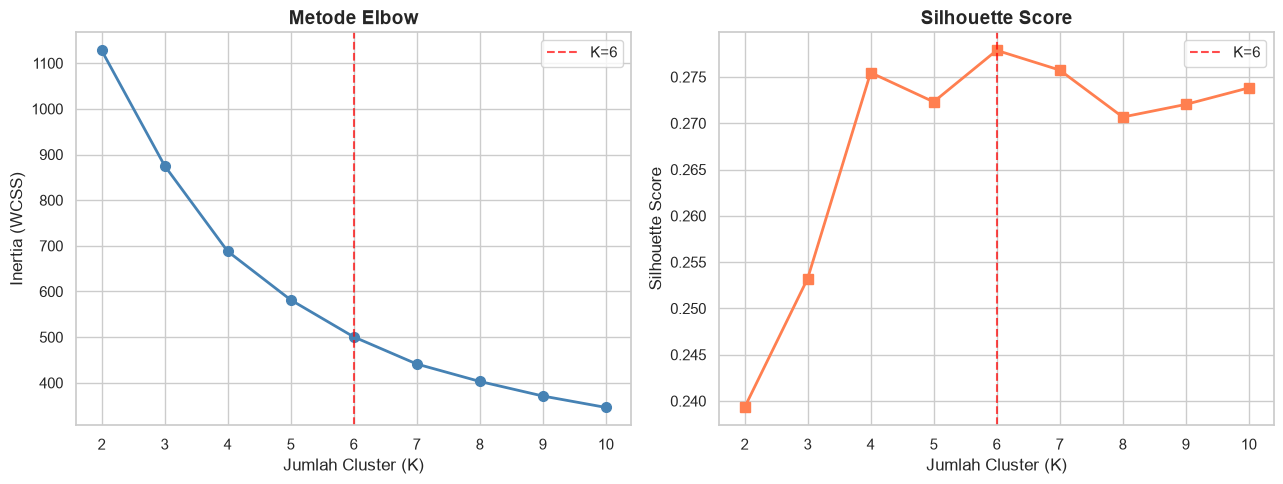

In [9]:
inertia_list = []
silhouette_list = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

best_k = list(K_range)[np.argmax(silhouette_list)]
print(f"K optimal (Silhouette tertinggi): K={best_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22','#8E44AD','#2C3E50','#27AE60']

axes[0].plot(list(K_range), inertia_list, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'K={best_k}')
axes[0].set_title('Metode Elbow', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

axes[1].plot(list(K_range), silhouette_list, 's-', color='coral', linewidth=2, markersize=7)
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'K={best_k}')
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. K-Means Clustering

In [10]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"\nDistribusi Cluster:")
print(df['Cluster'].value_counts().sort_index())

Silhouette Score: 0.2779

Distribusi Cluster:
Cluster
0    93
1    87
2    82
3    81
4    77
5    80
Name: count, dtype: int64


## 6. Visualisasi Hasil Clustering

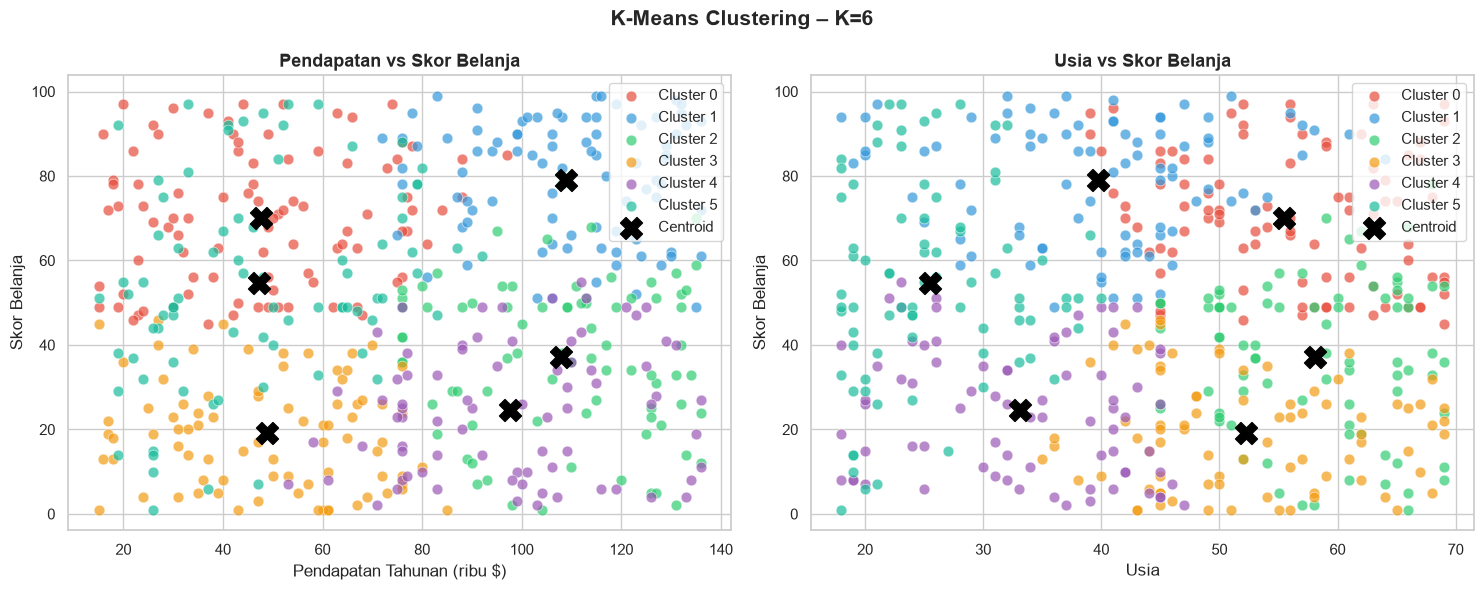

In [11]:
# Scatter: Income vs Spending Score
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)

for c in range(best_k):
    mask = df['Cluster'] == c
    axes[0].scatter(df.loc[mask, 'Annual_Income_k'], df.loc[mask, 'Spending_Score'],
                   s=60, color=COLORS[c], alpha=0.7, label=f'Cluster {c}', edgecolors='white', linewidth=0.5)
axes[0].scatter(centers_orig[:, 1], centers_orig[:, 2], s=250, c='black', marker='X', zorder=5, label='Centroid')
axes[0].set_title('Pendapatan vs Skor Belanja', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pendapatan Tahunan (ribu $)')
axes[0].set_ylabel('Skor Belanja')
axes[0].legend()

for c in range(best_k):
    mask = df['Cluster'] == c
    axes[1].scatter(df.loc[mask, 'Age'], df.loc[mask, 'Spending_Score'],
                   s=60, color=COLORS[c], alpha=0.7, label=f'Cluster {c}', edgecolors='white', linewidth=0.5)
axes[1].scatter(centers_orig[:, 0], centers_orig[:, 2], s=250, c='black', marker='X', zorder=5, label='Centroid')
axes[1].set_title('Usia vs Skor Belanja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Usia')
axes[1].set_ylabel('Skor Belanja')
axes[1].legend()

plt.suptitle(f'K-Means Clustering – K={best_k}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

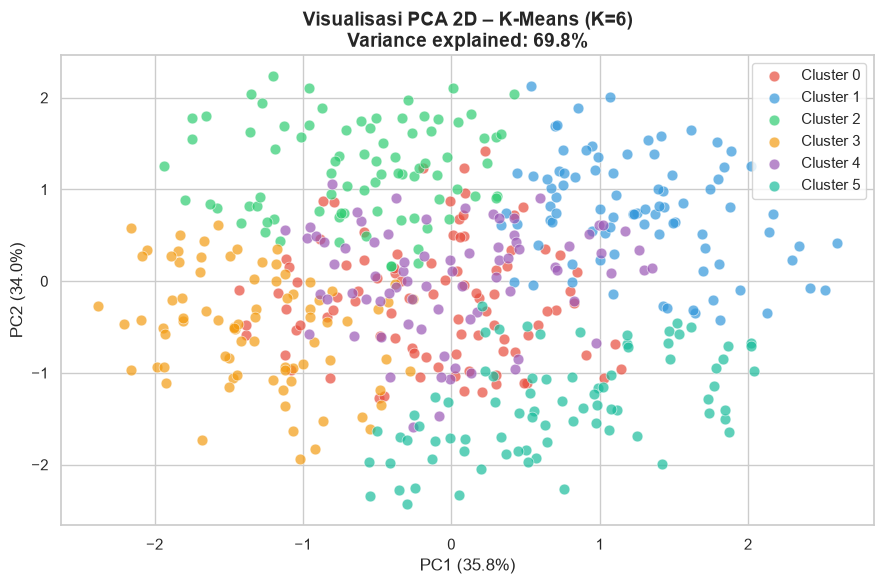

In [12]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(best_k):
    mask = df['Cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=60, color=COLORS[c],
               alpha=0.7, label=f'Cluster {c}', edgecolors='white', linewidth=0.5)

ax.set_title(f'Visualisasi PCA 2D – K-Means (K={best_k})\nVariance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evaluasi dan Profil Cluster

Profil Rata-Rata Setiap Cluster:
           Age  Annual_Income_k  Spending_Score
Cluster                                        
0        55.47            47.70           70.17
1        39.72           108.91           79.10
2        58.12           107.94           37.26
3        52.28            48.84           19.14
4        33.16            97.64           24.52
5        25.52            47.18           54.66


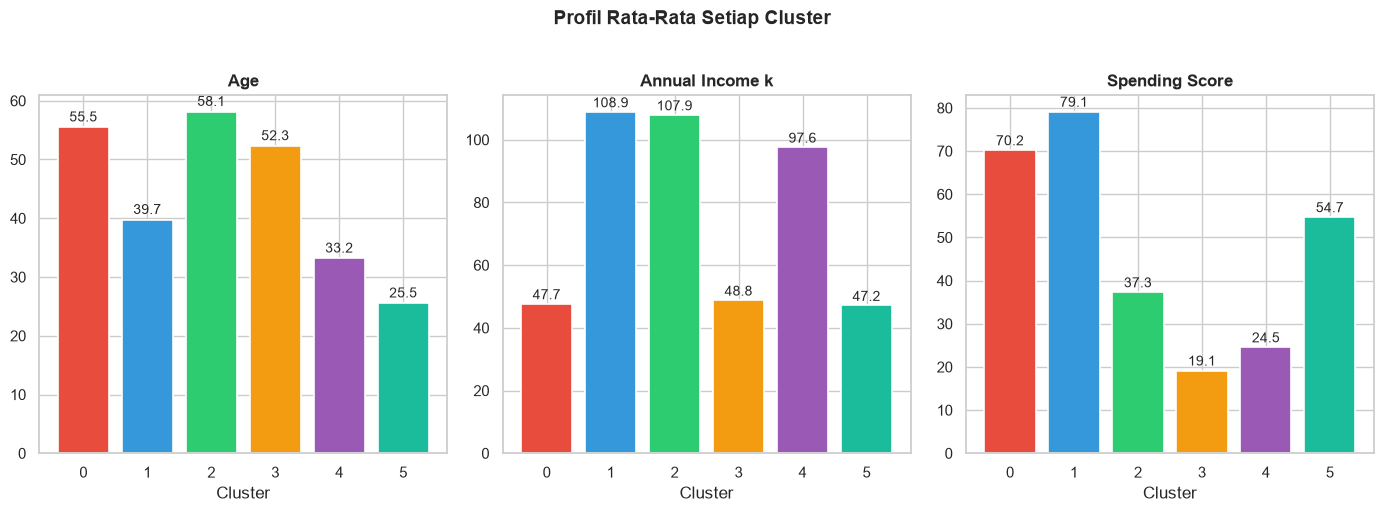

In [13]:
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
print("Profil Rata-Rata Setiap Cluster:")
print(cluster_profile)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, feat in enumerate(features):
    vals = cluster_profile[feat].values
    bars = axes[i].bar(range(best_k), vals, color=COLORS[:best_k], edgecolor='white', linewidth=1.2)
    axes[i].set_title(feat.replace('_', ' '), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks(range(best_k))
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Profil Rata-Rata Setiap Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Interpretasi Cluster

| Cluster | Usia | Pendapatan | Skor Belanja | Label Segmen |
|---------|------|-----------|--------------|--------------|
| 0 | Tua | Rendah | Tinggi | *Konsumen Setia Hemat* |
| 1 | Dewasa | Tinggi | Tinggi | *Konsumen Premium* |
| 2 | Tua | Tinggi | Rendah | *Kaya tapi Selektif* |
| 3 | Tua | Rendah | Rendah | *Konsumen Pasif* |
| 4 | Muda | Tinggi | Rendah | *Potensial, belum terkonversi* |
| 5 | Muda | Rendah | Sedang | *Konsumen Muda Aktif* |

---
**Catatan:** Label di atas bersifat interpretatif berdasarkan nilai rata-rata setiap cluster.

In [14]:
# Simpan hasil
df.to_csv('mall_customers_clustered.csv', index=False)
print("Dataset hasil clustering disimpan!")
print(f"Shape: {df.shape}")

Dataset hasil clustering disimpan!
Shape: (500, 7)
